# Race-Bias Hate Crime Rate vs. Neighbourhood Diversity

This notebook analyses race-motivated hate crimes per capita across Toronto neighbourhoods and correlates the rate with visible minority population (%) from the census.

CREDIT TO YEN HO AND SADIA TASNIM for this analysis.

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as path_effects
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
import geopandas as gpd
import contextily as ctx
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## 2. Helper — Make a Choropleth Map

In [3]:
def _choropleth(gdf_plot, column, title, cbar_label, cmap, out_file=None, label_col=None):
    """
    Draw a choropleth map with an optional basemap and polygon centroid labels.

    Parameters
    ----------
    label_col : str, optional
        Column whose value is printed at each polygon's representative point.
        Pass SHP_JOIN_COL to show neighbourhood numbers.
    out_file : str, optional
        If provided, saves the figure to this path.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Grey fill for unmatched polygons
    gdf_plot[gdf_plot[column].isna()].plot(
        ax=ax, color="#cccccc", edgecolor="white", linewidth=0.3
    )

    # Choropleth layer
    gdf_plot[gdf_plot[column].notna()].plot(
        column=column,
        ax=ax,
        cmap=cmap,
        edgecolor="white",
        linewidth=0.3,
        alpha=0.80,
        legend=True,
        legend_kwds={
            "label": cbar_label,
            "orientation": "vertical",
            "shrink": 0.6,
            "pad": 0.02,
        }
    )

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Neighbourhood number labels at representative points
    if label_col:
        label_gdf = gdf_plot[[label_col, "geometry"]].copy()
        label_gdf["_pt"] = label_gdf.geometry.representative_point()

        for _, row in label_gdf.iterrows():
            val = row[label_col]
            if pd.isna(val):
                continue
            ax.annotate(
                text=str(int(val)),
                xy=(row["_pt"].x, row["_pt"].y),
                ha="center", va="center",
                fontsize=5.5, fontweight="bold", color="black",
                path_effects=[
                    path_effects.withStroke(linewidth=2, foreground="white")
                ],
            )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=14)
    ax.set_axis_off()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_file}")

    plt.show()

## 3. Data Loading

In [4]:
crimes_df    = pd.read_csv("data/hatecrimes.csv")
diversity_df = pd.read_csv("data/minority.csv")

print(f"crimes_df    : {crimes_df.shape[0]:,} rows, {crimes_df.shape[1]} columns")
print(f"diversity_df : {diversity_df.shape[0]:,} rows, {diversity_df.shape[1]} columns")
crimes_df.head(3)

crimes_df    : 1,805 rows, 25 columns
diversity_df : 158 rows, 16 columns


,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,AGE_BIAS,MENTAL_OR_PHYSICAL_DISABILITY,RACE_BIAS,ETHNICITY_BIAS,LANGUAGE_BIAS,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE
0,1,GO-2020813480,2014,2014-08-01,1200,2020,2020-04-30,1904,D33,Religious Place of Worship/Cultural Centre,NO,NO,NaN,NaN,NaN,Jewish,NaN,NaN,No,Wilful Promotion of Hatred,053,Henry Farm (53),053,Henry Farm (53),No
1,2,GO-2019601581,2016,2016-01-01,900,2019,2019-04-03,1956,D42,"House (Townhouse, Retirement Home, Garage, Vehicle, Cottage)",NO,NO,NaN,NaN,NaN,NaN,Gay,NaN,No,This should be removed,144,Morningside Heights (144),131,Rouge (131),No
2,3,GO-2019728283,2016,2016-09-01,0,2019,2019-04-23,754,D53,"Educational Institution (Universities, Colleges, Schools, etc.)",NO,NO,Black,NaN,NaN,NaN,NaN,NaN,No,Assault With a Weapon,173,North Toronto (173),104,Mount Pleasant West (104),No


## Ensure there are 158 Unique Neighbourhoods in the Neighbourhood stats

In [5]:
n_unique = diversity_df["Neighbourhood Number"].nunique()
n_rows   = len(diversity_df)

print(f"Unique neighbourhood IDs  : {n_unique}")
print(f"Total rows in diversity_df: {n_rows}")

if n_unique == 158:
    print("✓ Confirmed: 158 unique neighbourhoods.")
else:
    print(f"✗ WARNING: Expected 158, found {n_unique}. Check for duplicates or missing entries.")
    dupes = diversity_df[diversity_df.duplicated("Neighbourhood Number", keep=False)]
    if not dupes.empty:
        print("\nDuplicate neighbourhood IDs:")
        display(dupes[["Neighbourhood Number"]])

Unique neighbourhood IDs  : 158
Total rows in diversity_df: 158
✓ Confirmed: 158 unique neighbourhoods.


## 5. Count Race-Bias Incidents per Neighbourhood

In [6]:
# Keep only rows where RACE_BIAS is non-null, non-blank, and not "NONE"
race_bias_df = crimes_df[
    crimes_df["RACE_BIAS"].notna() &
    (crimes_df["RACE_BIAS"].astype(str).str.strip() != "") &
    (crimes_df["RACE_BIAS"].astype(str).str.upper() != "NONE")
].copy()

incident_counts = (
    race_bias_df
    .groupby("HOOD_158", as_index=False)
    .size()
    .rename(columns={"HOOD_158": "Neighbourhood Number", "size": "race_bias_count"})
)

print(f"Total race-bias incidents        : {race_bias_df.shape[0]:,}")
print(f"Neighbourhoods with ≥1 incident  : {len(incident_counts)}")
incident_counts.sort_values("race_bias_count", ascending=False).head(10)

Total race-bias incidents        : 540
Neighbourhoods with ≥1 incident  : 140


,Neighbourhood Number,race_bias_count
134,170,25
59,073,20
132,168,17
131,167,16
19,027,15
69,088,13
128,164,12
60,074,11
130,166,11
77,098,10


## 6. Merge & Clean data

In [7]:
# Align join key dtypes
diversity_df["Neighbourhood Number"] = pd.to_numeric(
    diversity_df["Neighbourhood Number"], errors="coerce"
)
incident_counts["Neighbourhood Number"] = pd.to_numeric(
    incident_counts["Neighbourhood Number"], errors="coerce"
)

merged = diversity_df.merge(incident_counts, on="Neighbourhood Number", how="left")
merged["race_bias_count"] = merged["race_bias_count"].fillna(0)

# Compute Percent Of Minority from raw counts
merged["Percent Of Minority"] = (
    merged["  Total visible minority population"] / merged["Total"]
)

# Clean population column
merged["Total"] = pd.to_numeric(
    merged["Total"].astype(str).str.replace(",", ""), errors="coerce"
)
merged["Percent Of Minority"] = pd.to_numeric(
    merged["Percent Of Minority"].astype(str).str.replace("%", "").str.strip(),
    errors="coerce"
)

# Drop rows with missing or zero population
before = len(merged)
merged = merged[merged["Total"].notna() & (merged["Total"] > 0)].copy()
after  = len(merged)
if before != after:
    print(f"⚠ Dropped {before - after} row(s) with missing/zero population.")

print(f"Rows after cleaning: {len(merged)}")
merged[["Neighbourhood Number", "Total", "Percent Of Minority", "race_bias_count"]].head()

Rows after cleaning: 158


,Neighbourhood Number,Total,Percent Of Minority,race_bias_count
0,1,33300,0.841892,5.0
1,2,31345,0.892487,0.0
2,3,9850,0.680711,0.0
3,4,10375,0.576867,1.0
4,5,9355,0.691074,2.0


## 7. Normalize Rate (calculate per capita crime, i.e. per 10,000 residents)

In [8]:
SCALE = 10_000
merged["race_bias_per_capita"] = (merged["race_bias_count"] / merged["Total"]) * SCALE

print(f"Per-capita metric : incidents per {SCALE:,} residents")
print(f"Mean rate         : {merged['race_bias_per_capita'].mean():.4f}")
print(f"Max  rate         : {merged['race_bias_per_capita'].max():.4f}")
merged[["Neighbourhood Number", "Total", "Percent Of Minority", "race_bias_per_capita"]].head()

Per-capita metric : incidents per 10,000 residents
Mean rate         : 2.0057
Max  rate         : 19.7707


,Neighbourhood Number,Total,Percent Of Minority,race_bias_per_capita
0,1,33300,0.841892,1.501502
1,2,31345,0.892487,0.000000
2,3,9850,0.680711,0.000000
3,4,10375,0.576867,0.963855
4,5,9355,0.691074,2.137894


## 8. Identify Outliers (or High-Influence Points)

In [9]:
reg_df = (
    merged[["Neighbourhood Number", "Percent Of Minority", "race_bias_per_capita"]]
    .dropna()
    .copy()
    .reset_index(drop=True)
)

X_full = sm.add_constant(reg_df["Percent Of Minority"])
y_full = reg_df["race_bias_per_capita"]

model_full        = sm.OLS(y_full, X_full).fit()
cooks_d_full      = OLSInfluence(model_full).cooks_distance[0]
outlier_threshold = 4 / int(model_full.nobs)
outlier_idx       = np.where(cooks_d_full > outlier_threshold)[0]
outlier_hoods     = reg_df.loc[outlier_idx, "Neighbourhood Number"].tolist()

print(f"Cook's D threshold (4/n) : {outlier_threshold:.4f}")
print(f"High-influence points    : {len(outlier_idx)}")
print(f"Neighbourhood Numbers    : {sorted([int(h) for h in outlier_hoods])}\n")

if len(outlier_idx):
    detail = reg_df.iloc[outlier_idx].copy()
    detail["Cooks_D"] = cooks_d_full[outlier_idx]
    display(
        detail[["Neighbourhood Number", "Percent Of Minority", "race_bias_per_capita", "Cooks_D"]]
        .sort_values("Cooks_D", ascending=False)
        .style.format({"Percent Of Minority": "{:.1%}", "race_bias_per_capita": "{:.4f}", "Cooks_D": "{:.4f}"})
    )

Cook's D threshold (4/n) : 0.0253
High-influence points    : 4
Neighbourhood Numbers    : [66, 73, 168, 170]



,Neighbourhood Number,Percent Of Minority,race_bias_per_capita,Cooks_D
153,170,71.6%,19.7707,0.3357
60,66,28.5%,10.7411,0.0946
151,168,58.1%,9.6072,0.0364
67,73,51.2%,9.3045,0.0309


## 9. Remove Outliers

In [10]:
reg_df_clean = reg_df.drop(index=outlier_idx).reset_index(drop=True)

X_clean = sm.add_constant(reg_df_clean["Percent Of Minority"])
y_clean = reg_df_clean["race_bias_per_capita"]

model     = sm.OLS(y_clean, X_clean).fit()
beta0     = model.params["const"]
beta1     = model.params["Percent Of Minority"]
p_val_b1  = model.pvalues["Percent Of Minority"]
r_squared = model.rsquared
n_obs     = int(model.nobs)

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     race_bias_per_capita   R-squared:                       0.033
Model:                              OLS   Adj. R-squared:                  0.027
Method:                   Least Squares   F-statistic:                     5.257
Date:                  Mon, 16 Mar 2026   Prob (F-statistic):             0.0232
Time:                          17:42:38   Log-Likelihood:                -280.27
No. Observations:                   154   AIC:                             564.5
Df Residuals:                       152   BIC:                             570.6
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

## 10. Create Scatter Plot with Regression Line

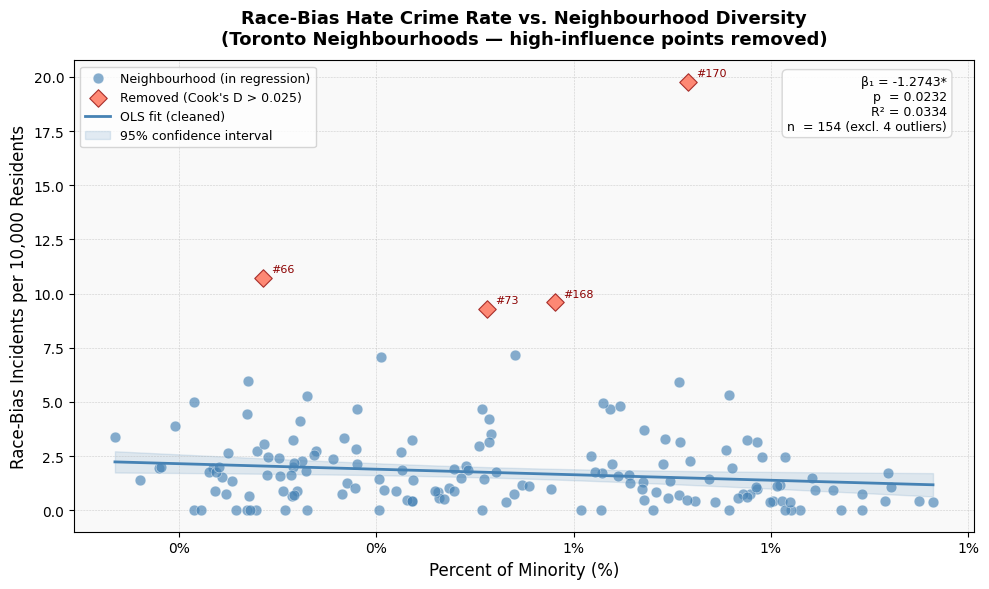

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Clean points
ax.scatter(
    reg_df_clean["Percent Of Minority"],
    reg_df_clean["race_bias_per_capita"],
    c="steelblue", alpha=0.65, edgecolors="white", linewidths=0.4,
    s=60, zorder=3, label="Neighbourhood (in regression)"
)

# Removed outliers — plotted but excluded from fit
if len(outlier_idx):
    outlier_rows = reg_df.iloc[outlier_idx]
    ax.scatter(
        outlier_rows["Percent Of Minority"],
        outlier_rows["race_bias_per_capita"],
        c="tomato", alpha=0.75, edgecolors="darkred", linewidths=0.8,
        s=80, marker="D", zorder=4,
        label=f"Removed (Cook's D > {outlier_threshold:.3f})"
    )
    for _, row in outlier_rows.iterrows():
        ax.annotate(
            f"#{int(row['Neighbourhood Number'])}",
            xy=(row["Percent Of Minority"], row["race_bias_per_capita"]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=8, color="darkred"
        )

# Regression line + 95% CI
x_range = np.linspace(reg_df_clean["Percent Of Minority"].min(),
                      reg_df_clean["Percent Of Minority"].max(), 200)
pred_df = model.get_prediction(sm.add_constant(x_range)).summary_frame(alpha=0.05)

ax.plot(x_range, pred_df["mean"], color="steelblue", linewidth=2,
        zorder=5, label="OLS fit (cleaned)")
ax.fill_between(x_range, pred_df["mean_ci_lower"], pred_df["mean_ci_upper"],
                color="steelblue", alpha=0.15, label="95% confidence interval")

# Stats annotation
sig_star = "***" if p_val_b1 < 0.001 else "**" if p_val_b1 < 0.01 else "*" if p_val_b1 < 0.05 else "ns"
stats_text = (
    f"β₁ = {beta1:.4f}{sig_star}\n"
    f"p  = {p_val_b1:.4f}\n"
    f"R² = {r_squared:.4f}\n"
    f"n  = {n_obs} (excl. {len(outlier_idx)} outlier{'s' if len(outlier_idx) != 1 else ''})"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="lightgray", alpha=0.9))

ax.set_xlabel("Percent of Minority (%)", fontsize=12)
ax.set_ylabel(f"Race-Bias Incidents per {SCALE:,} Residents", fontsize=12)
ax.set_title(
    "Race-Bias Hate Crime Rate vs. Neighbourhood Diversity\n"
    "(Toronto Neighbourhoods — high-influence points removed)",
    fontsize=13, fontweight="bold", pad=12
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

## 11. Summary Table

In [12]:
summary = (
    merged[["Neighbourhood Number", "race_bias_count",
            "Total", "Percent Of Minority", "race_bias_per_capita"]]
    .sort_values("race_bias_per_capita", ascending=False)
    .head(20)
    .rename(columns={
        "Neighbourhood Number": "Hood #",
        "race_bias_count":      "Incidents",
        "Total":                "Population",
        "Percent Of Minority":  "% Minority",
        "race_bias_per_capita": "Incidents/10k"
    })
)
summary.style.format({"Population": "{:,.0f}", "% Minority": "{:.2%}", "Incidents/10k": "{:.4f}"})

,Hood #,Incidents,Population,% Minority,Incidents/10k
153,170,25.000000,"12,645",71.57%,19.7707
60,66,10.000000,"9,310",28.52%,10.7411
151,168,17.000000,"17,695",58.10%,9.6072
67,73,20.000000,"21,495",51.17%,9.3045
150,167,16.000000,"22,320",54.08%,7.1685
15,18,8.000000,"11,345",40.50%,7.0516
78,88,13.000000,"21,855",27.02%,5.9483
68,74,11.000000,"18,535",70.65%,5.9347
23,27,15.000000,"28,255",75.74%,5.3088
16,19,6.000000,"11,360",33.01%,5.2817


## 12. Load Neighborhood Shapefile & Merge

In [13]:
gdf = gpd.read_file("data/Neighbourhoods - 4326.shp")

print(f"CRS       : {gdf.crs}")
print(f"Rows      : {len(gdf)}")
print(f"Columns   : {list(gdf.columns)}")

CRS       : EPSG:4326
Rows      : 158
Columns   : ['_id1', 'AREA_ID2', 'AREA_AT3', 'PARENT_4', 'AREA_SH5', 'AREA_LO6', 'AREA_NA7', 'AREA_DE8', 'CLASSIF9', 'CLASSIF10', 'OBJECTI11', 'geometry']


In [14]:
SHP_JOIN_COL = "AREA_SH5"   # ← update if your shapefile uses a different column

gdf[SHP_JOIN_COL] = pd.to_numeric(gdf[SHP_JOIN_COL], errors="coerce")

# Reproject to Web Mercator (required by contextily)
gdf = gdf.to_crs(epsg=3857)

plot_gdf = gdf.merge(
    merged[["Neighbourhood Number", "Percent Of Minority", "race_bias_per_capita"]],
    left_on=SHP_JOIN_COL,
    right_on="Neighbourhood Number",
    how="left"
)

missing = plot_gdf["Percent Of Minority"].isna().sum()
if missing:
    print(f"⚠ {missing} polygon(s) had no match in merged data — will appear grey.")
else:
    print("✓ All polygons matched successfully.")

✓ All polygons matched successfully.


## 13. Choropleth of Visible Minority % (Diversity)

  Saved: choropleth_diversity.png


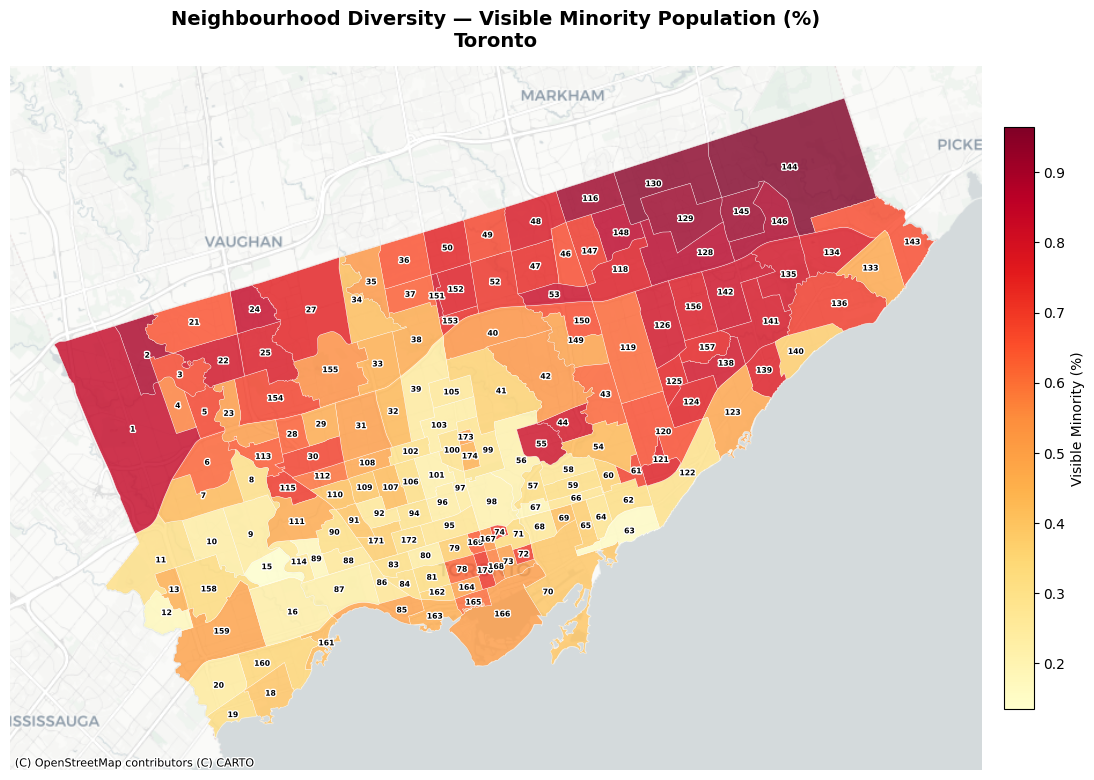

In [15]:
_choropleth(
    gdf_plot  = plot_gdf,
    column    = "Percent Of Minority",
    title     = "Neighbourhood Diversity — Visible Minority Population (%)\nToronto",
    cbar_label= "Visible Minority (%)",
    cmap      = "YlOrRd",
    out_file  = "choropleth_diversity.png",
    label_col = SHP_JOIN_COL,
)

## 14.Choropleth of Race-Bias Incidents per 10,000 Residents in the TPS database

  Saved: choropleth_race_bias_per_capita.png


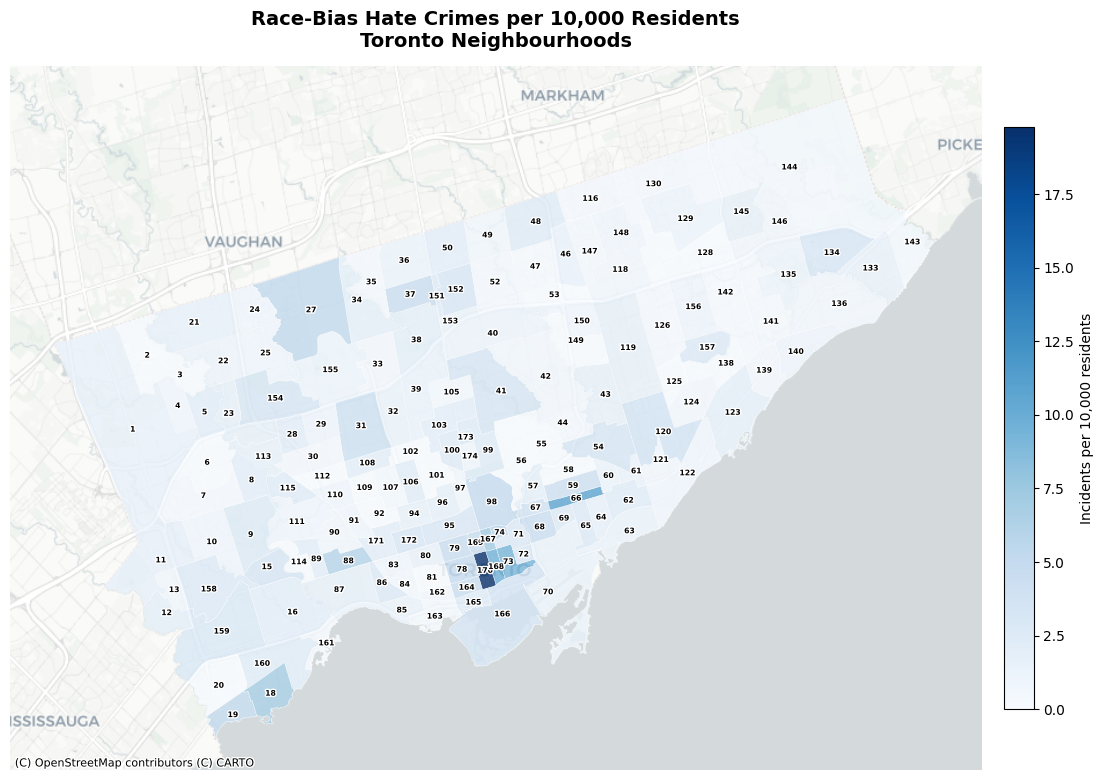

In [30]:
_choropleth(
    gdf_plot  = plot_gdf,
    column    = "race_bias_per_capita",
    title     = f"Race-Bias Hate Crimes per {SCALE:,} Residents\nToronto Neighbourhoods",
    cbar_label= f"Incidents per {SCALE:,} residents",
    cmap      = "Blues",
    out_file  = "choropleth_race_bias_per_capita.png",
    label_col = SHP_JOIN_COL,
)